# GBM Examples Notebook

Original QMCPy demo: [`QMCPy/demos/GBM/gbm_examples.ipynb`](../../../QMCPy/demos/GBM/gbm_examples.ipynb)

The Python notebook compares GBM sampler errors through helper modules, including MAE trends in the number of paths and time steps. This Julia translation keeps those same two GBM error sweeps with direct `QuasiMC.jl` routines, then adds a lightweight Asian-option estimate and representative sample paths as explicit Julia extensions.

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/QMCSoftware/QuasiMC.jl/blob/develop/demos/GBM/gbm_examples.ipynb)

Parity note: this Julia notebook keeps the same path-count and time-step MAE sweeps as the QMCPy source, but replaces the Python helper-module and QuantLib wiring with direct `QuasiMC.jl` terminal-mean checks. The later Asian-option and sample-path sections are labeled as Julia extensions.


In [1]:
using QuasiMC
using Statistics
using Printf

# Plots.jl is optional; guard plot cells so the notebook runs in headless CI.
const HAVE_PLOTS = Base.find_package("Plots") !== nothing
HAVE_PLOTS && @eval using Plots
if HAVE_PLOTS
    Plots.default(
        titlefont=Plots.font(9),
        plot_titlefont=Plots.font(11),
        left_margin=4Plots.mm,
        right_margin=8Plots.mm,
        top_margin=8Plots.mm,
        bottom_margin=5Plots.mm,
    )
end


## Configuration

We work with a geometric Brownian motion model

$$S(t) = S_0 \exp\!\left((\gamma - 	\frac{\sigma^2}{2}) t + \sigma W(t)
\right),$$

and compare how the sampling error changes with the number of simulated paths and time steps.


In [2]:
S0 = 100.0
γ = 0.05
σ2 = 0.04
T = 1.0
d = 8
ns = 2 .^ (7:11)
exact_terminal_mean = S0 * exp(γ * T)

function terminal_mean_error(dd)
    tm = GeometricBrownianMotion(dd; t_final=T, initial_value=S0, drift=γ, diffusion=σ2)
    x = transform(tm, gen_samples(dd, ns[end]))
    return [abs(mean(x[1:n, end]) - exact_terminal_mean) for n in ns]
end

iid_errors = terminal_mean_error(IIDStdUniform(d; seed=7))
lattice_errors = terminal_mean_error(Lattice(d; seed=7))
net_errors = terminal_mean_error(DigitalNetB2(d; seed=7, graycode=false))

println("path counts = ", ns)
println("IID errors = ", round.(iid_errors, digits=4))
println("Lattice errors = ", round.(lattice_errors, digits=4))
println("Digital net errors = ", round.(net_errors, digits=4))


path counts = 

[128, 256, 512, 1024, 2048]
IID errors = 

[3.5637, 2.5423, 1.1599, 0.1958, 0.3603]
Lattice errors = [0.0263, 0.1759, 0.093, 0.0182, 0.0157]
Digital net errors = [0.1431, 0.2135, 0.0169, 0.0209, 0.0688]


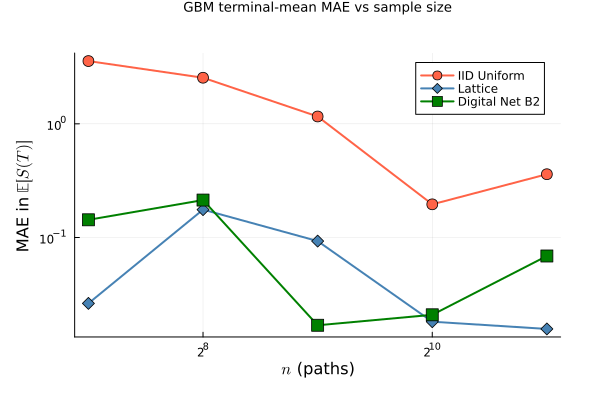

In [3]:
if HAVE_PLOTS
    p = plot(ns, iid_errors;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:tomato, label="IID Uniform",
        xlabel="\$n\$ (paths)", ylabel="MAE in \$\\mathbb{E}[S(T)]\$",
        title="GBM terminal-mean MAE vs sample size")
    plot!(ns, lattice_errors;
        marker=:diamond, lw=2, ms=6, color=:steelblue, label="Lattice")
    plot!(ns, net_errors;
        marker=:square, lw=2, ms=6, color=:green, label="Digital Net B2")
    display(p)
end


## MAE vs Number of Paths in QMCPy and QuantLib

The exact mean of the terminal stock price is available in closed form, so the absolute error of the empirical terminal mean is the direct Julia analogue of the path-count MAE comparison used in the Python notebook.


In [4]:
@assert minimum(lattice_errors) < maximum(iid_errors)
@assert minimum(net_errors) < maximum(iid_errors)


## MAE vs Number of Time Steps in QMCPy and QuantLib

We now repeat the same terminal-mean MAE comparison while varying the number of Brownian time steps, which mirrors the second shared sweep from the QMCPy notebook.


time steps = 

[16, 32, 64, 128, 256, 512]
IID step errors = [0.0274, 0.0442, 0.0379, 0.0339, 0.0311, 0.0327]
Lattice step errors = [0.0112, 0.0079, 0.0027, 0.0035, 0.002, 0.006]
Digital net step errors = [0.0035, 0.0178, 0.0228, 0.0233, 0.0099, 0.0005]


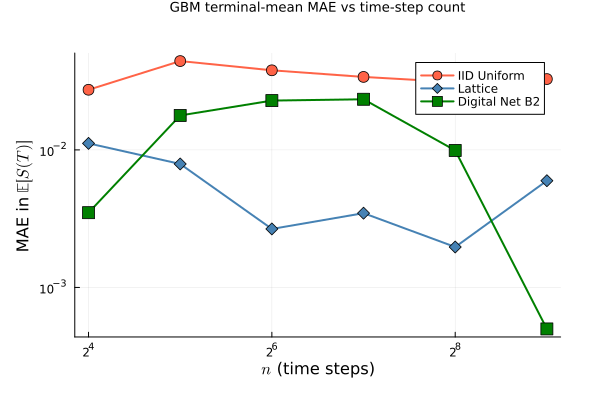

In [5]:
steps = 2 .^ (4:9)
fixed_paths = 2^12

function terminal_mean_error_vs_steps(dd_ctor)
    errs = Float64[]
    for n_steps in steps
        dd = dd_ctor(n_steps)
        tm = GeometricBrownianMotion(dd; t_final=T, initial_value=S0, drift=γ, diffusion=σ2)
        x = transform(tm, gen_samples(dd, fixed_paths))
        push!(errs, abs(mean(x[:, end]) - exact_terminal_mean))
    end
    return errs
end

iid_step_errors = terminal_mean_error_vs_steps(d -> IIDStdUniform(d; seed=7))
lattice_step_errors = terminal_mean_error_vs_steps(d -> Lattice(d; seed=7))
net_step_errors = terminal_mean_error_vs_steps(d -> DigitalNetB2(d; seed=7, graycode=false))

println("time steps = ", steps)
println("IID step errors = ", round.(iid_step_errors, digits=4))
println("Lattice step errors = ", round.(lattice_step_errors, digits=4))
println("Digital net step errors = ", round.(net_step_errors, digits=4))

@assert minimum(lattice_step_errors) < maximum(iid_step_errors)
@assert minimum(net_step_errors) < maximum(iid_step_errors)

if HAVE_PLOTS
    p_steps = plot(steps, iid_step_errors;
        xscale=:log2, yscale=:log10,
        marker=:circle, lw=2, ms=6, color=:tomato, label="IID Uniform",
        xlabel="\$n\$ (time steps)", ylabel="MAE in \$\\mathbb{E}[S(T)]\$",
        title="GBM terminal-mean MAE vs time-step count")
    plot!(steps, lattice_step_errors;
        marker=:diamond, lw=2, ms=6, color=:steelblue, label="Lattice")
    plot!(steps, net_step_errors;
        marker=:square, lw=2, ms=6, color=:green, label="Digital Net B2")
    display(p_steps)
end


**Julia extension: Asian Option Example.**

As a second GBM-based example, we price a geometric-average Asian call option using a randomized lattice rule.


In [6]:
tm_option = BrownianMotion(Lattice(12; seed=7); t_final=1.0)
asian_call = FinancialOption(tm_option; option_type=:asian, call_put=:call, mean_type=:geometric, volatility=0.5, start_price=30.0, strike_price=25.0, interest_rate=0.0)
result_option = integrate(CubQMCLatticeG(asian_call; abs_tol=5e-3))
@printf("Geometric Asian call price estimate = %.6f using n_total = %d
", result_option.solution, result_option.data[:n_total])
@printf("Closed-form benchmark used by QuasiMC.jl = %.6f
", get_exact_value(asian_call))

@assert abs(result_option.solution - get_exact_value(asian_call)) < 0.1


Geometric Asian call price estimate = 5.948500 using n_total = 16384
Closed-form benchmark used by QuasiMC.jl = 5.951824


**Julia extension: Sample Paths Visualization.**


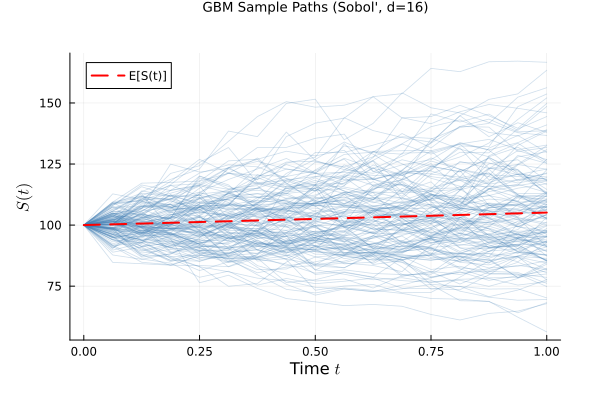

In [7]:
if HAVE_PLOTS
    S0_plot, γ_plot, σ2_plot = 100.0, 0.05, 0.04
    T_plot = 1.0
    d_plot = 16
    n_show = 150
    dd_plt = DigitalNetB2(d_plot; seed=7)
    gbm_plt = GeometricBrownianMotion(dd_plt;
        t_final=T_plot, initial_value=S0_plot, drift=γ_plot, diffusion=σ2_plot)
    x_plt = gen_samples(dd_plt, n_show)
    paths_plt = transform(gbm_plt, x_plt)
    t_plt = [0.0; gbm_plt.time_vector]
    S_plt = hcat(fill(S0_plot, n_show), paths_plt)  # n_show × (d_plot+1)
    p = plot(t_plt, S_plt';
        alpha=0.25, color=:steelblue, lw=0.8, label=nothing,
        xlabel="Time \$t\$", ylabel="\$S(t)\$",
        title="GBM Sample Paths (Sobol', d=$d_plot)")
    E_line = S0_plot .* exp.(γ_plot .* gbm_plt.time_vector)
    plot!([0.0; gbm_plt.time_vector], [S0_plot; E_line];
        color=:red, lw=2, linestyle=:dash, label="E[S(t)]")
    display(p)
end
